# Recurrent Neural Network

### Fariz Saputra ( 23051030002 ) 

### Dataset : 
###     - Latitude  : -7.756033501338686
###     - Longitude : 110.39991625583852

## Part 1 - Data Preprocessing

### Importing the libraries

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Importing the training set

In [11]:
dataset = pd.read_csv(r"D:\ML\RNN rev\data_cuaca_terbaru.csv", sep=';')
data = dataset.iloc[:,1:2].values
training_data_len = int(len(data) * 0.8)

train_data = data[:training_data_len]
test_data = data[training_data_len:]

In [12]:
print("Jumlah Total Data :", len(data))
print("Jumlah Training Data :", len(train_data))
print("Jumlah Testing Data :", len(test_data))

Jumlah Total Data : 11880
Jumlah Training Data : 9504
Jumlah Testing Data : 2376


### Feature Scaling

In [13]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0,1))
training_set_scaled = sc.fit_transform(train_data)

### Creating a data structure with 60 timesteps and 1 output

In [14]:
x_train = []
y_train = []

for i in range(60, len(training_set_scaled)):
    x_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

### Reshaping

In [15]:
X_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

## Part 2 - Building and Training the RNN

### Importing the Keras libraries and packages

In [16]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout

### Initialising the RNN

In [17]:
regressor = Sequential()

### Adding the first LSTM layer and some Dropout regularisation

In [18]:
regressor.add(LSTM(units = 50, return_sequences = True, input_shape = (X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

c:\Users\VICTUS\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Adding a second LSTM layer and some Dropout regularisation

In [19]:
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

### Adding a third LSTM layer and some Dropout regularisation

In [20]:
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

### Adding a fourth LSTM layer and some Dropout regularisation

In [21]:
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))

### Adding the output layer

In [22]:
regressor.add(Dense(units = 1))

### Compiling the RNN

In [23]:
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

### Fitting the RNN to the Training set

In [24]:
history = regressor.fit(x_train,
                        y_train,
                        epochs = 100,
                        batch_size = 32)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - loss: 0.0218
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 0.0075
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 0.0068
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 0.0063
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 0.0060
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 0.0058
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 0.0054
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 0.0052
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 0.0048
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 0.0046
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 0.0041
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 0.0039
Epoch 13/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 0.0036
Epoch 14/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 0.0032
Epoch 15/100
29

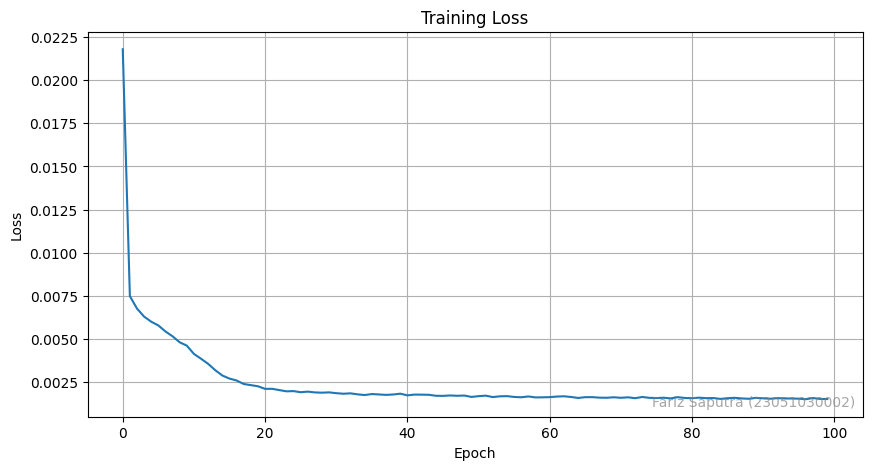

In [25]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.text(0.99,
         0.02,
         'Fariz Saputra (23051030002)',
         fontsize=10,
         color='gray',
         ha='right',
         va='bottom',
         alpha=0.7,
         transform=plt.gca().transAxes)
plt.show()

## Part 3 - Making the predictions and visualising the results

### Getting the real temperature data

In [26]:
real_temperature = test_data


### Predicting temperature using RNN

In [27]:
dataset_total = data

inputs = dataset_total[len(dataset_total)
                       - len(test_data)
                       - 60:]

inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)
x_test = []
for i in range(60, len(inputs)):
    x_test.append(inputs[i-60:i,0])
x_test = np.array(x_test)
x_test = np.reshape(x_test,
                    (x_test.shape[0],
                     x_test.shape[1],
                     1))
predicted_temperature = regressor.predict(x_test)
predicted_temperature = sc.inverse_transform(predicted_temperature)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


### Visualising the results

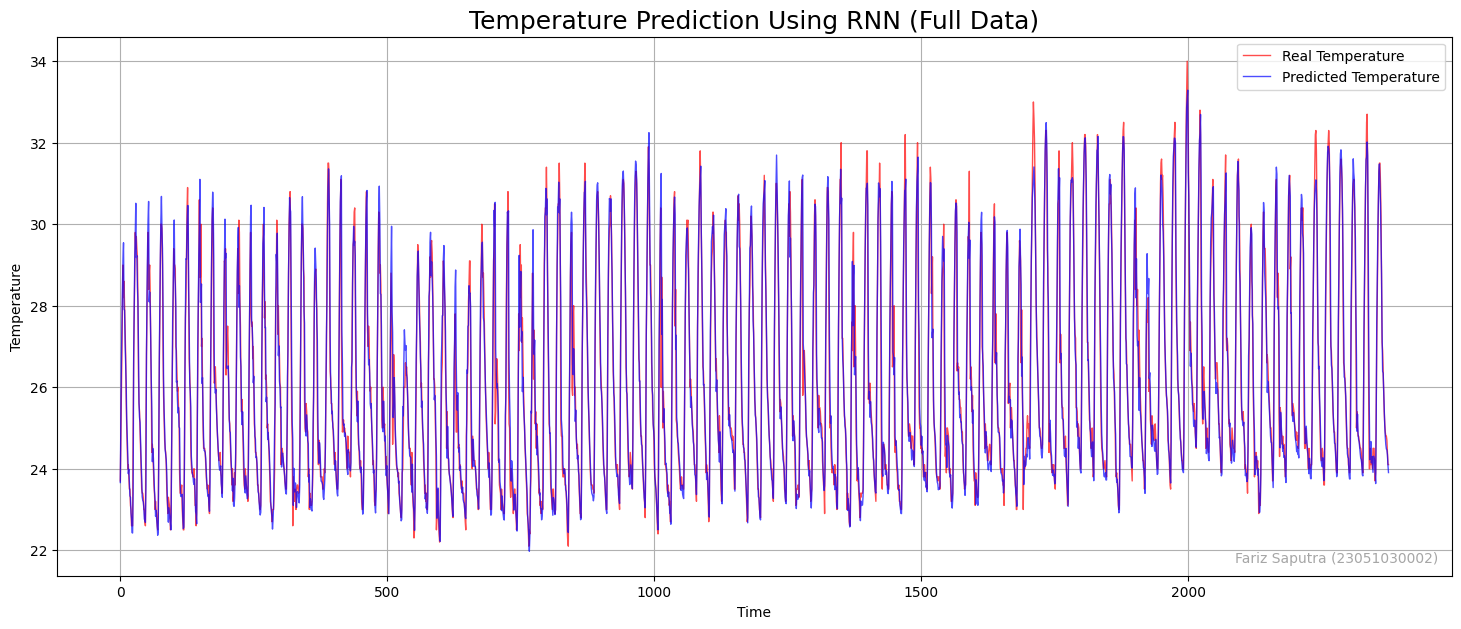

In [28]:
plt.figure(figsize=(18,7))

plt.plot(real_temperature,
         color='red',
         linewidth=1,
         alpha=0.7,
         label='Real Temperature')
plt.plot(predicted_temperature,
         color='blue',
         linewidth=1,
         alpha=0.7,
         label='Predicted Temperature')
plt.title('Temperature Prediction Using RNN (Full Data)',
          fontsize=18)
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.text(0.99,
         0.02,
         'Fariz Saputra (23051030002)',
         fontsize=10,
         color='gray',
         ha='right',
         va='bottom',
         alpha=0.7,
         transform=plt.gca().transAxes)
plt.show()

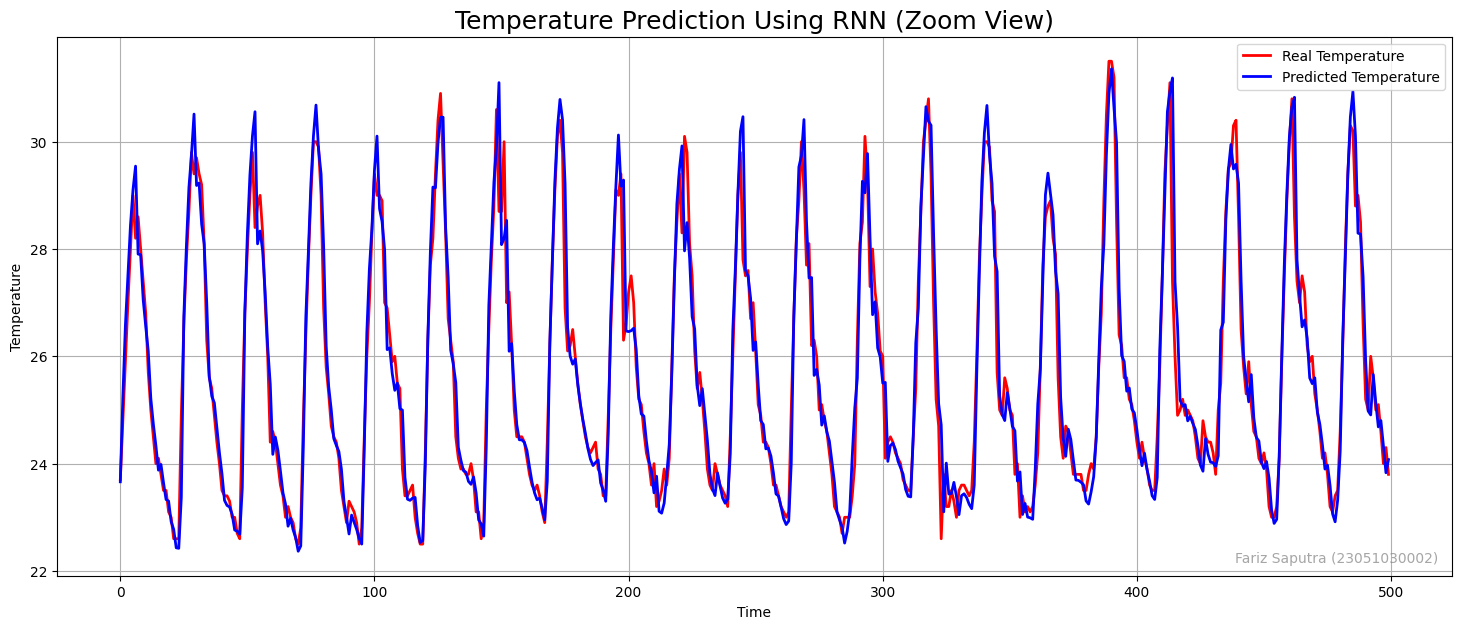

In [29]:
plt.figure(figsize=(18,7))
plt.plot(real_temperature[:500],
         color='red',
         linewidth=2,
         label='Real Temperature')
plt.plot(predicted_temperature[:500],
         color='blue',
         linewidth=2,
         label='Predicted Temperature')
plt.title('Temperature Prediction Using RNN (Zoom View)',
          fontsize=18)
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.text(0.99,
         0.02,
         'Fariz Saputra (23051030002)',
         fontsize=10,
         color='gray',
         ha='right',
         va='bottom',
         alpha=0.7,
         transform=plt.gca().transAxes)
plt.show()

## Model Evaluation Using RMSE

In [30]:
from sklearn.metrics import mean_squared_error
import math
rmse = math.sqrt(mean_squared_error(real_temperature,
                                    predicted_temperature))
print("RMSE :", round(rmse,2))

RMSE : 0.64
